# 🌏 KDM Declustering — New Zealand Earthquake Catalogue
### Kohonen Map Declustering Method (Septier et al.)

**Goal:** Separate ~380,000 NZ earthquake events into:
- 🔴 **Crisis events** — aftershocks & swarms (triggered by other quakes)
- 🔵 **Non-crisis events** — background seismicity (independent quakes)

**Method:** Self-Organising Map (SOM) + Agglomerative Clustering + Probabilistic Classification

---
### Pipeline Overview
```
Load CSV → Clean → Build 22 Features → Train SOM (4×4) → Cluster Nodes
         → Compute Centroids → Probabilistic Classification → Label Events → Save + Plot
```
---
> **Your dataset already has all 22 features pre-computed:** T1–T10, R1–R10, Mn, bval ✅

## 📦 Step 0 — Install Required Libraries
Run this cell once in your terminal or uncomment the `!pip` line.

In [7]:
# Uncomment and run once if libraries are not installed:
# !pip install minisom scikit-learn pandas numpy scipy matplotlib seaborn

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import AgglomerativeClustering
from minisom import MiniSom
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Output directory for saving plots and results
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

def out(filename):
    """Helper to build output file path."""
    return str(OUTPUT_DIR / filename)

print('✅ All libraries loaded successfully!')

ModuleNotFoundError: No module named 'sklearn'

In [8]:
pip install minisom scikit-learn pandas numpy scipy matplotlib seaborn

  Using cached minisom-2.3.6-py3-none-any.whl
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl (8.1 MB)
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/37.3 MB ? eta -:--:--
    --------------------------------------- 0.5/37.3 MB 1.2 MB/s eta 0:00:30
    --------------------------------------- 0.8/37.3 MB 1.2 MB/s eta 0:00:31
   - -------------------------------------- 1.3/37.3 MB 1.4 MB/s eta 0:00:27
   - -------------------------------------- 1.6/37.3 MB 1.3 MB/s eta 0:00:28
   - -------------------------------------- 1.8/37.3 MB 1.3 MB/s eta 0:00:28
   -- ------------------------------------- 2.1/37.3 MB 1.4 MB/s eta 0:00:26
   -- 

---
## 📂 Step 1 — Load & Clean Your Data

- Load your NZ earthquake CSV file
- Drop rows missing T1–T10, R1–R10, Mn, or bval
- Drop events with `i+ = 0` (no neighbours computed yet)

> 🔧 **Change `YOUR_CSV` to your actual file path before running.**

In [9]:
# ── CHANGE THIS to your actual CSV file path ──────────────────
YOUR_CSV = r'C:\Users\HP\Desktop\SOM_KDM_METHOD\som_feature_nz_real_catalog.csv'
# ───────────────────────────────────────────────────────────────

def load_nz_data(filepath):
    df = pd.read_csv(filepath, low_memory=False)
    print(f'Raw data shape: {df.shape}')
    print(f'Columns ({len(df.columns)}): {list(df.columns)}')
    return df


def clean_data(df):
    t_cols   = [f'T{i}' for i in range(1, 11)]
    r_cols   = [f'R{i}' for i in range(1, 11)]
    required = t_cols + r_cols + ['Mn', 'bval']

    # df_clean = df.dropna(subset=required).copy()
    df_clean = df.copy()
    df_clean[required] = df_clean[required].fillna(0)

    # Drop events with no neighbours yet (i+ = 0)
    if 'i+' in df_clean.columns:
        before = len(df_clean)
        df_clean = df_clean[df_clean['i+'] > 0].copy()
        print(f'  Removed {before - len(df_clean):,} events with i+=0')

    print(f'Clean data shape : {df_clean.shape}')
    print(f'Removed {len(df) - len(df_clean):,} rows total')
    return df_clean.reset_index(drop=True)


# Run
df      = load_nz_data(YOUR_CSV)
df_clean = clean_data(df)
df_clean.head(3)

Raw data shape: (352517, 44)
Columns (44): ['event', 'date', 'Time', 'latitude', 'longitude', 'depth', 'magnitude', 'DateTime', 'time', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'Second', 'i+', 'N+', 'T+', 'R+', 'dm+', 'n_child', 'n_parent', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9', 'R10', 'Mn', 'bval']
  Removed 1 events with i+=0
Clean data shape : (352516, 44)
Removed 1 rows total


,event,date,Time,latitude,longitude,depth,magnitude,DateTime,time,Year,...,R3,R4,R5,R6,R7,R8,R9,R10,Mn,bval
0,3,1980-01-01,18:28:10.99,-37.63,176.38000,210.0,4.150,1980-01-01 18:28:10.990,0.475062,1980,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,4,1980-01-01,20:20:54.03,-40.29,173.42999,212.0,4.500,1980-01-01 20:20:54.030,0.553338,1980,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,5,1980-01-02,18:24:15.40,-38.48,176.75000,5.0,3.375,1980-01-02 18:24:15.400,1.472336,1980,...,0.123085,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### 🔍 Quick Data Check — Verify Feature Columns Exist

In [10]:
t_cols = [f'T{i}' for i in range(1, 11)]
r_cols = [f'R{i}' for i in range(1, 11)]

print('Temporal features (T1-T10):', all(c in df_clean.columns for c in t_cols))
print('Spatial features  (R1-R10):', all(c in df_clean.columns for c in r_cols))
print('Mn column        :', 'Mn'   in df_clean.columns)
print('bval column      :', 'bval' in df_clean.columns)
print()
print('Feature value ranges:')
feature_cols = t_cols + r_cols + ['Mn', 'bval']
df_clean[feature_cols].describe().round(4)

Temporal features (T1-T10): True
Spatial features  (R1-R10): True
Mn column        : True
bval column      : True

Feature value ranges:


,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,...,R3,R4,R5,R6,R7,R8,R9,R10,Mn,bval
count,352516.0000,352516.0000,352516.0000,352516.0000,352516.0000,352516.0000,352516.0000,352516.0000,352516.0000,352516.0000,...,352516.0000,352516.0000,352516.0000,352516.0000,352516.0000,352516.0000,352516.0000,352516.0000,352516.0000,3.525160e+05
mean,2.1409,2.2537,2.6062,2.8436,3.0153,3.1842,3.3188,3.3982,3.5450,3.6788,...,0.0173,0.0192,0.0210,0.0185,0.0198,0.0213,0.0211,0.0210,1.0000,4.931758e+03
std,16.4913,13.9559,15.9782,16.5705,16.7390,16.9210,17.0052,16.8873,17.7934,18.2179,...,0.3231,0.9739,0.9213,0.3183,0.5757,0.6624,1.0191,0.5628,0.0460,4.625950e+05
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4985,0.000000e+00
25%,0.0008,0.0020,0.0033,0.0045,0.0057,0.0070,0.0080,0.0092,0.0104,0.0114,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.000000e+00
50%,0.0085,0.0196,0.0304,0.0401,0.0501,0.0591,0.0677,0.0761,0.0838,0.0918,...,0.0003,0.0003,0.0003,0.0004,0.0004,0.0004,0.0004,0.0004,1.0000,0.000000e+00
75%,0.1052,0.2119,0.3054,0.3918,0.4761,0.5480,0.6198,0.6826,0.7400,0.7980,...,0.0035,0.0038,0.0040,0.0042,0.0044,0.0045,0.0047,0.0048,1.0000,1.145900e+00
max,729.3435,541.2845,582.9736,660.0473,646.2906,644.3700,676.1588,652.8144,758.4373,714.5768,...,94.4671,543.4495,467.9203,123.8416,226.2551,226.6280,563.8230,174.4947,1.8978,4.342945e+07


---
## 🧮 Step 2 — Build the 22-Dimensional Feature Matrix

The SOM uses **22 features per event** (from the paper, Table 2):

| Features | Columns | Meaning |
|---|---|---|
| T1–T10 | Temporal distances | Time gap to 10 nearest neighbours |
| R1–R10 | Spatial distances  | Distance to 10 nearest neighbours |
| Mn     | Magnitude ratio    | STA/LTA-style magnitude anomaly |
| bval   | Local b-value      | Gutenberg-Richter slope |

> **Why normalise?** SOM uses Euclidean distances — all features must be on [0,1] scale.

In [13]:
from sklearn.preprocessing import MinMaxScaler
def build_feature_matrix(df):
    t_cols = [f'T{i}' for i in range(1, 11)]
    r_cols = [f'R{i}' for i in range(1, 11)]
    feature_cols = t_cols + r_cols + ['Mn', 'bval']

    X = df[feature_cols].values.astype(np.float32)

    # Replace NaN / Inf with 0
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    # Scale to [0, 1] — critical for SOM
    scaler   = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    print(f'Feature matrix shape : {X_scaled.shape}')
    print(f'Features             : {feature_cols}')
    return X_scaled, feature_cols, scaler


X_scaled, feature_cols, scaler = build_feature_matrix(df_clean)
print(f'\nMemory usage: {X_scaled.nbytes / 1e6:.1f} MB')

Feature matrix shape : (352516, 22)
Features             : ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9', 'R10', 'Mn', 'bval']

Memory usage: 31.0 MB


---
## 🧠 Step 3 — Train the Self-Organising Map (SOM)

**Hyperparameters (from paper Table 1):**

| Parameter | Value | Why |
|---|---|---|
| Grid size | 4×4 = 16 nodes | Best for 2-class problem |
| Iterations | 100,000 | Enough for convergence |
| Samples | 7,000–140,000 | Large datasets need more |

**How SOM works:**
1. Start with 16 random neurons on a 4×4 grid
2. For each earthquake, find the closest neuron (**BMU** = Best Matching Unit)
3. Move that neuron + its neighbours slightly toward the earthquake
4. Repeat → neurons settle into meaningful clusters

> ⏱️ **Expected time:** ~5–25 minutes for 380k events on a laptop.
> Increase `n_samples=140000` if you have >16GB RAM.

In [15]:
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import AgglomerativeClustering
from minisom import MiniSom           # pip install minisom
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.spatial.distance import cdist
# ── HYPERPARAMETERS — adjust as needed ──────────────────────
GRID_SIZE    = 4        # 4×4 = 16 nodes (paper recommendation)
N_ITERATIONS = 100_000  # training iterations
N_SAMPLES    = 7_000    # increase to 140_000 if RAM allows
RANDOM_SEED  = 42
# ─────────────────────────────────────────────────────────────


def train_som_batch(X_scaled, grid_size=4, n_iterations=100_000,
                    n_samples=7_000, random_seed=42):
    n_features = X_scaled.shape[1]
    som = MiniSom(
        x=grid_size, y=grid_size,
        input_len=n_features,
        sigma=1.5,
        learning_rate=0.5,
        random_seed=random_seed
    )
    # PCA initialisation → faster convergence
    som.pca_weights_init(X_scaled)

    # Subsample for training
    idx     = np.random.choice(len(X_scaled),
                               size=min(n_samples, len(X_scaled)),
                               replace=False)
    X_train = X_scaled[idx]

    print(f'Training SOM: {grid_size}×{grid_size} grid | '
          f'{n_features} features | '
          f'{n_iterations:,} iterations | '
          f'{len(X_train):,} training samples')

    som.train_random(X_train, n_iterations, verbose=True)
    print('\n✅ SOM training complete!')
    return som


som = train_som_batch(
    X_scaled,
    grid_size    = GRID_SIZE,
    n_iterations = N_ITERATIONS,
    n_samples    = N_SAMPLES,
    random_seed  = RANDOM_SEED
)

Training SOM: 4×4 grid | 22 features | 100,000 iterations | 7,000 training samples
 [ 100000 / 100000 ] 100% - 0:00:00 left 
 quantization error: 0.029075928022276695

✅ SOM training complete!


---
## 📊 Step 4 — Check SOM Training Quality

Two metrics confirm the SOM learned well:

| Metric | Meaning | Good value |
|---|---|---|
| **QE** (Quantisation Error) | Average distance between event and its neuron | As small as possible |
| **TE** (Topological Error)  | How well 2D structure preserves neighbourhoods | Close to 0 |

> If QE and TE are stable (not changing between runs) → training is sufficient.

In [16]:
def compute_som_errors(som, X_scaled, n_check=10_000):
    """Use a subsample for speed on large datasets."""
    idx    = np.random.choice(len(X_scaled), min(n_check, len(X_scaled)),
                              replace=False)
    X_sub  = X_scaled[idx]
    qe = som.quantization_error(X_sub)
    te = som.topographic_error(X_sub)
    print(f'Quantisation Error (QE) : {qe:.4f}  ← lower is better')
    print(f'Topological Error  (TE) : {te:.4f}  ← closer to 0 is better')
    return qe, te



qe, te = compute_som_errors(som, X_scaled)

Quantisation Error (QE) : 0.0282  ← lower is better
Topological Error  (TE) : 0.0894  ← closer to 0 is better



🔍 Starting SOM Hyperparameter Tuning


Testing → grid=3x3  sigma=0.8  lr=0.05  samples=140000
QE=0.0338  TE=0.0388

Testing → grid=3x3  sigma=0.8  lr=0.05  samples=150000
QE=0.0312  TE=0.1116

Testing → grid=3x3  sigma=0.8  lr=0.05  samples=200000
QE=0.0311  TE=0.0221

Testing → grid=3x3  sigma=0.8  lr=0.3  samples=140000
QE=0.0364  TE=0.7634

Testing → grid=3x3  sigma=0.8  lr=0.3  samples=150000
QE=0.0347  TE=0.0078

Testing → grid=3x3  sigma=0.8  lr=0.3  samples=200000
QE=0.0343  TE=0.9417

Testing → grid=3x3  sigma=0.8  lr=0.5  samples=140000
QE=0.0388  TE=0.3219

Testing → grid=3x3  sigma=0.8  lr=0.5  samples=150000
QE=0.0399  TE=0.0269

Testing → grid=3x3  sigma=0.8  lr=0.5  samples=200000
QE=0.0355  TE=0.0062

Testing → grid=3x3  sigma=0.8  lr=0.7  samples=140000
QE=0.0448  TE=0.0830

Testing → grid=3x3  sigma=0.8  lr=0.7  samples=150000
QE=0.0351  TE=0.0062

Testing → grid=3x3  sigma=0.8  lr=0.7  samples=200000
QE=0.0355  TE=0.0356

Testing → grid=3x3  sigma=1.2  lr=0.05  sampl

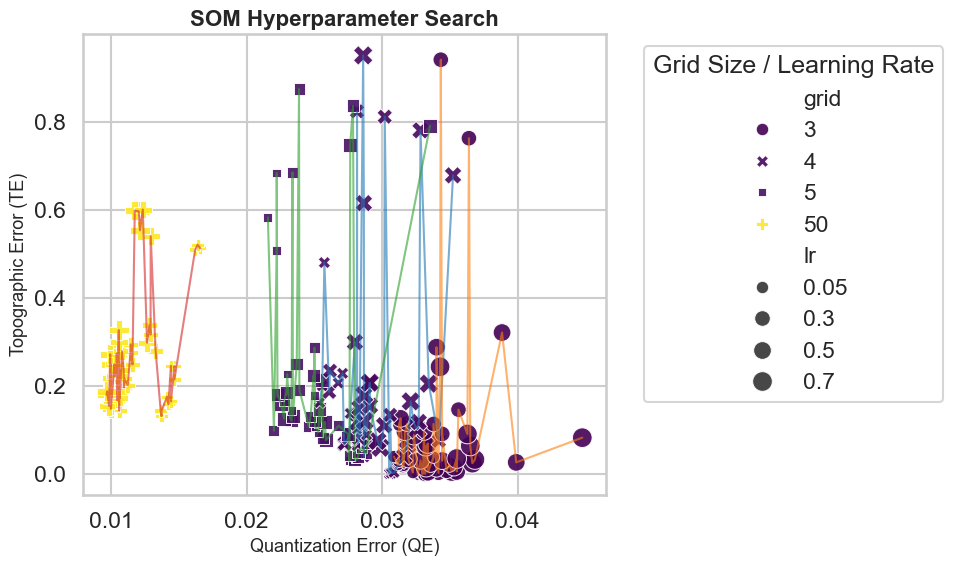

In [19]:
# ============================================================
# SOM TRAINING + HYPERPARAMETER TUNING
# ============================================================

import numpy as np
import pandas as pd
from minisom import MiniSom
import matplotlib.pyplot as plt
import seaborn as sns


# ── BASE PARAMETERS ─────────────────────────────────────────
GRID_SIZE    = 4
N_ITERATIONS = 100_000
N_SAMPLES    = 7_000
RANDOM_SEED  = 42


# ============================================================
# SOM ERROR METRICS
# ============================================================

def compute_som_errors(som, X):
    """
    Evaluate SOM quality using:
    QE → Quantization Error
    TE → Topographic Error
    """
    qe = som.quantization_error(X)
    te = som.topographic_error(X)
    return qe, te


# ============================================================
# HYPERPARAMETER TUNING
# ============================================================

def tune_som_hyperparameters(
        X_scaled,
        grid_sizes=[3,4,5,50],
        sigmas=[0.8,1.2,1.5,2.0],
        learning_rates=[0.05,0.3,0.5,0.7],
        n_iterations=20000,
        n_samples=[140000,150000,200000],
        random_seed=42):

    results = []

    print("\n🔍 Starting SOM Hyperparameter Tuning\n")

    for g in grid_sizes:
        for s in sigmas:
            for lr in learning_rates:
                for ns in n_samples:
    
                    print(f"\nTesting → grid={g}x{g}  sigma={s}  lr={lr}  samples={ns}")
    
                    n_features = X_scaled.shape[1]
    
                    som = MiniSom(
                        x=g,
                        y=g,
                        input_len=n_features,
                        sigma=s,
                        learning_rate=lr,
                        random_seed=random_seed
                    )
    
                    som.pca_weights_init(X_scaled)
    
                    idx = np.random.choice(
                        len(X_scaled),
                        size=min(ns, len(X_scaled)),
                        replace=False
                    )
    
                    X_train = X_scaled[idx]
    
                    som.train_random(X_train, n_iterations)
    
                    qe, te = compute_som_errors(som, X_train)
    
                    results.append({
                        "grid": g,
                        "sigma": s,
                        "lr": lr,
                        "n_samples": ns,
                        "QE": qe,
                        "TE": te
                    })
    
                    print(f"QE={qe:.4f}  TE={te:.4f}")

    results_df = pd.DataFrame(results)

    # combined score
    results_df["score"] = results_df["QE"] + results_df["TE"]

    results_df = results_df.sort_values("score")

    print("\n🏆 BEST PARAMETERS")
    print(results_df.head(5))

    best = results_df.iloc[0]

    return best, results_df


# ============================================================
# FINAL SOM TRAINING
# ============================================================

def train_som_batch(X_scaled,
                    grid_size,
                    sigma,
                    learning_rate,
                    n_iterations=100000,
                    n_samples=7000,
                    random_seed=42):

    n_features = X_scaled.shape[1]

    som = MiniSom(
        x=grid_size,
        y=grid_size,
        input_len=n_features,
        sigma=sigma,
        learning_rate=learning_rate,
        random_seed=random_seed
    )

    som.pca_weights_init(X_scaled)

    idx = np.random.choice(
        len(X_scaled),
        size=min(n_samples, len(X_scaled)),
        replace=False
    )

    X_train = X_scaled[idx]

    print(
        f"\nTraining FINAL SOM → "
        f"{grid_size}x{grid_size} grid | "
        f"sigma={sigma} | "
        f"lr={learning_rate} | "
        f"{n_iterations:,} iterations"
    )

    som.train_random(X_train, n_iterations, verbose=True)

    print("\n✅ SOM training complete!")

    return som


# ============================================================
# RUN HYPERPARAMETER SEARCH
# ============================================================

best_params, tuning_results = tune_som_hyperparameters(X_scaled)

print("\nBest configuration found:")
print(best_params)


# ============================================================
# TRAIN FINAL MODEL
# ============================================================

som = train_som_batch(
    X_scaled,
    grid_size     = int(best_params["grid"]),
    sigma         = float(best_params["sigma"]),
    learning_rate = float(best_params["lr"]),
    n_iterations  = N_ITERATIONS,
    n_samples     = N_SAMPLES,
    random_seed   = RANDOM_SEED
)


# ============================================================
# VISUALIZE TUNING RESULTS
# ============================================================

plt.figure(figsize=(10,6))

sns.set_style("whitegrid")
sns.set_context("talk")

# Scatter points
scatter = sns.scatterplot(
    data=tuning_results,
    x="QE",
    y="TE",
    hue="grid",
    style="grid",
    size="lr",
    sizes=(80,200),
    palette="viridis",
    alpha=0.9
)

# Connect points belonging to same grid size
for g in tuning_results["grid"].unique():
    subset = tuning_results[tuning_results["grid"] == g]
    subset = subset.sort_values("QE")
    
    plt.plot(
        subset["QE"],
        subset["TE"],
        linewidth=1.5,
        alpha=0.6
    )

plt.title("SOM Hyperparameter Search", fontsize=16, weight="bold")
plt.xlabel("Quantization Error (QE)", fontsize=13)
plt.ylabel("Topographic Error (TE)", fontsize=13)

plt.legend(title="Grid Size / Learning Rate", bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()

plt.show()

---
## 🗺️ Step 5 — Assign Each Event to Its Best Matching Unit (BMU)

Every earthquake is mapped to one of the 16 SOM neurons — its 'home node'.
Events on the same node are **seismically similar** in feature space.

In [20]:
def assign_bmu(som, X_scaled):
    print('Assigning all events to BMU nodes...')
    bmu_list = np.array([som.winner(x) for x in X_scaled])
    # Show distribution across nodes
    bmu_flat = bmu_list[:, 0] * som._weights.shape[1] + bmu_list[:, 1]
    unique, counts = np.unique(bmu_flat, return_counts=True)
    print(f'BMU assignment done. Shape: {bmu_list.shape}')
    print(f'Events per node — min: {counts.min():,}  '
          f'max: {counts.max():,}  '
          f'mean: {counts.mean():.0f}')
    return bmu_list


bmu_list = assign_bmu(som, X_scaled)

Assigning all events to BMU nodes...
BMU assignment done. Shape: (352516, 2)
Events per node — min: 2,300  max: 136,153  mean: 22032


## That is ~39% of the entire catalogue in one neuron Meanwhile the smallest neuron has only: 2,300 events

In [34]:
bmu_counts = {}

for x in X_scaled:
    bmu = som.winner(x)
    bmu_counts[bmu] = bmu_counts.get(bmu,0)+1

print(sorted(bmu_counts.values()))

[2300, 3671, 5409, 6452, 7316, 10697, 11262, 13381, 17261, 20208, 21207, 21766, 23783, 24617, 27033, 136153]


# Again tune hyper parameters

In [ ]:
# ============================================================
# SOM TRAINING + HYPERPARAMETER TUNING (Improved Version)
# ============================================================

import numpy as np
import pandas as pd
from minisom import MiniSom
import matplotlib.pyplot as plt
import seaborn as sns


# ── BASE PARAMETERS ─────────────────────────────────────────
N_ITERATIONS = 100_000
RANDOM_SEED  = 42


# ============================================================
# SOM ERROR METRICS
# ============================================================

def compute_som_errors(som, X):
    """Compute Quantization Error and Topographic Error"""
    qe = som.quantization_error(X)
    te = som.topographic_error(X)
    return qe, te


# ============================================================
# BMU BALANCE METRIC (important for clustering)
# ============================================================

def compute_bmu_balance(som, X):

    counts = {}

    for x in X:
        bmu = som.winner(x)
        counts[bmu] = counts.get(bmu,0) + 1

    values = np.array(list(counts.values()))

    # coefficient of variation (lower = better balance)
    cv = values.std() / (values.mean()+1e-9)

    return cv


# ============================================================
# HYPERPARAMETER TUNING
# ============================================================

def tune_som_hyperparameters(
        X_scaled,
        grid_sizes=[5,6],               # removed pathological sizes
        sigmas=[0.8,1.0,1.2,1.5],         # more realistic sigma
        learning_rates=[0.1,0.3,0.5],     # remove unstable extremes
        n_iterations=20000,
        n_samples=[100000,150000],
        random_seed=42):

    results = []

    print("\n🔍 Starting SOM Hyperparameter Tuning\n")

    N = len(X_scaled)

    # validation subset for metrics
    val_idx = np.random.choice(N, 20000, replace=False)
    X_val = X_scaled[val_idx]

    for g in grid_sizes:
        for s in sigmas:

            # skip unrealistic sigma for grid size
            if s > g:
                continue

            for lr in learning_rates:
                for ns in n_samples:

                    print(f"\nTesting → grid={g}x{g}  sigma={s}  lr={lr}  samples={ns}")

                    som = MiniSom(
                        x=g,
                        y=g,
                        input_len=X_scaled.shape[1],
                        sigma=s,
                        learning_rate=lr,
                        random_seed=random_seed
                    )

                    som.pca_weights_init(X_scaled)

                    idx = np.random.choice(
                        N,
                        size=min(ns, N),
                        replace=False
                    )

                    X_train = X_scaled[idx]

                    som.train_random(X_train, n_iterations)

                    qe, te = compute_som_errors(som, X_val)

                    balance = compute_bmu_balance(som, X_val)

                    score = qe + te + 0.1*balance

                    results.append({
                        "grid": g,
                        "sigma": s,
                        "lr": lr,
                        "n_samples": ns,
                        "QE": qe,
                        "TE": te,
                        "balance": balance,
                        "score": score
                    })

                    print(
                        f"QE={qe:.4f}  "
                        f"TE={te:.4f}  "
                        f"balance={balance:.3f}"
                    )

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values("score")

    print("\n🏆 BEST PARAMETERS")
    print(results_df.head(5))

    best = results_df.iloc[0]

    return best, results_df


# ============================================================
# FINAL SOM TRAINING
# ============================================================

def train_som_batch(
        X_scaled,
        grid_size,
        sigma,
        learning_rate,
        n_iterations=100000,
        n_samples=150000,
        random_seed=42):

    n_features = X_scaled.shape[1]

    som = MiniSom(
        x=grid_size,
        y=grid_size,
        input_len=n_features,
        sigma=sigma,
        learning_rate=learning_rate,
        random_seed=random_seed
    )

    som.pca_weights_init(X_scaled)

    idx = np.random.choice(
        len(X_scaled),
        size=min(n_samples, len(X_scaled)),
        replace=False
    )

    X_train = X_scaled[idx]

    print(
        f"\nTraining FINAL SOM → "
        f"{grid_size}x{grid_size} grid | "
        f"sigma={sigma} | "
        f"lr={learning_rate}"
    )

    som.train_random(X_train, n_iterations, verbose=True)

    print("\n✅ SOM training complete!")

    return som


# ============================================================
# RUN HYPERPARAMETER SEARCH
# ============================================================

best_params, tuning_results = tune_som_hyperparameters(X_scaled)

print("\nBest configuration found:")
print(best_params)


# ============================================================
# TRAIN FINAL MODEL
# ============================================================

som = train_som_batch(
    X_scaled,
    grid_size     = int(best_params["grid"]),
    sigma         = float(best_params["sigma"]),
    learning_rate = float(best_params["lr"]),
    n_samples     = int(best_params["n_samples"]),
    n_iterations  = N_ITERATIONS
)


# ============================================================
# VISUALIZE TUNING RESULTS
# ============================================================

sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=tuning_results,
    x="QE",
    y="TE",
    hue="grid",
    size="lr",
    palette="viridis",
    alpha=0.9
)

plt.title("SOM Hyperparameter Search", fontsize=16, weight="bold")
plt.xlabel("Quantization Error (QE)")
plt.ylabel("Topographic Error (TE)")

plt.tight_layout()
plt.show()


🔍 Starting SOM Hyperparameter Tuning



TypeError: 'int' object is not iterable

In [37]:
bmu_counts = {}

for x in X_scaled:
    bmu = som.winner(x)
    bmu_counts[bmu] = bmu_counts.get(bmu,0)+1

print(sorted(bmu_counts.values()))

[972, 4338, 4676, 5404, 6417, 7236, 7997, 8166, 8597, 11817, 14813, 20764, 26695, 32405, 36943, 155276]


# U-Matrix (Unified Distance Matrix) is one of the most important diagnostics for SOM quality. It shows how different neighbouring neurons are, which reveals cluster boundaries.

For your earthquake declustering, it helps answer:

Are seismic regimes separated?

Are there distinct crisis clusters?

Did the SOM collapse into one region?

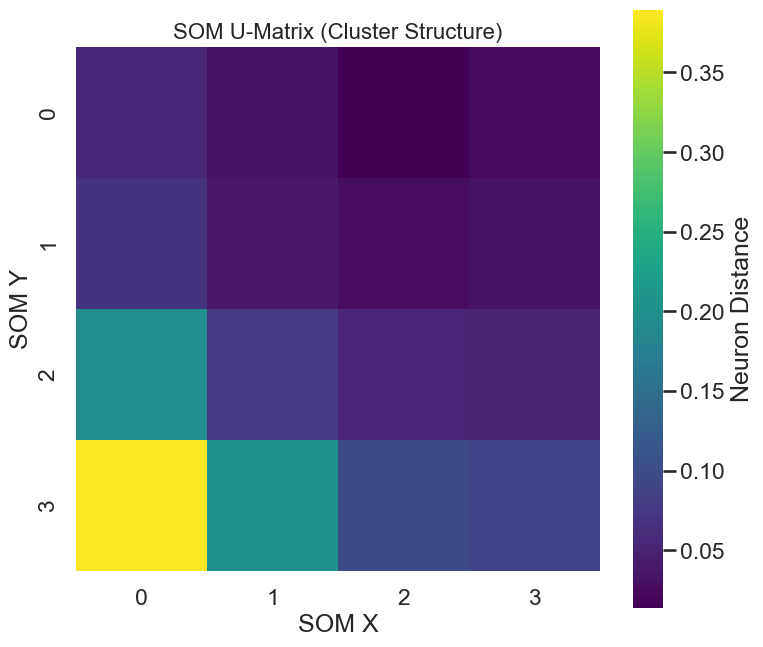

In [39]:
def plot_u_matrix(som):

    from scipy.spatial.distance import euclidean

    weights = som.get_weights()

    x = weights.shape[0]
    y = weights.shape[1]

    umat = np.zeros((x,y))

    for i in range(x):
        for j in range(y):

            neighbors = []

            if i > 0:
                neighbors.append(weights[i-1,j])
            if i < x-1:
                neighbors.append(weights[i+1,j])
            if j > 0:
                neighbors.append(weights[i,j-1])
            if j < y-1:
                neighbors.append(weights[i,j+1])

            dists = [euclidean(weights[i,j], n) for n in neighbors]

            umat[i,j] = np.mean(dists)

    plt.figure(figsize=(8,7))

    plt.title("SOM U-Matrix (Cluster Structure)", fontsize=16)

    sns.heatmap(
        umat,
        cmap="viridis",
        annot=False,
        square=True,
        cbar_kws={"label":"Neuron Distance"}
    )

    plt.xlabel("SOM X")
    plt.ylabel("SOM Y")

    plt.tight_layout()
    plt.show()
    
plot_u_matrix(som)

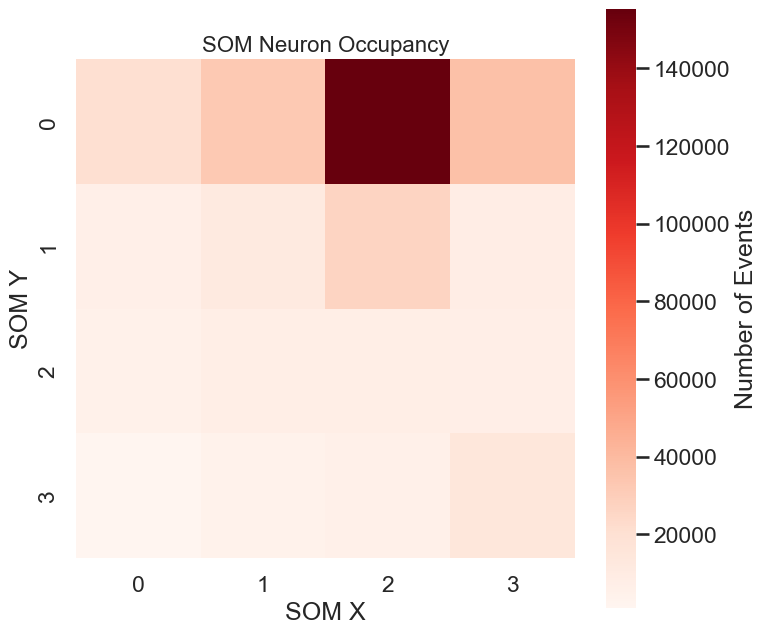

In [41]:
def plot_som_density(som, X_scaled):

    weights = som.get_weights()
    grid_x, grid_y = weights.shape[:2]

    density = np.zeros((grid_x, grid_y))

    for x in X_scaled:
        i, j = som.winner(x)
        density[i, j] += 1

    plt.figure(figsize=(8,7))

    sns.heatmap(
        density,
        cmap="Reds",
        square=True,
        cbar_kws={"label": "Number of Events"}
    )

    plt.title("SOM Neuron Occupancy", fontsize=16)
    plt.xlabel("SOM X")
    plt.ylabel("SOM Y")

    plt.tight_layout()
    plt.show()
    
plot_som_density(som, X_scaled)

---
## 🔗 Step 6 — Agglomerative Clustering on SOM Nodes

Group the 16 SOM neurons into meaningful seismic clusters.

- Uses **Ward linkage** (minimises within-cluster variance)
- Default: one cluster per node (`n_clusters = grid_size²`)
- Try reducing to 8 or 4 if you want coarser groupings

> The paper found 14–16 clusters for real datasets (Fig. 8).

In [21]:
def cluster_som_nodes(som, n_clusters=None):
    weights          = som.get_weights()               # (grid_x, grid_y, n_feat)
    grid_x, grid_y, n_feat = weights.shape
    w_flat           = weights.reshape(grid_x * grid_y, n_feat)

    if n_clusters is None:
        n_clusters = grid_x * grid_y

    clustering   = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    node_labels  = clustering.fit_predict(w_flat)
    node_labels_2d = node_labels.reshape(grid_x, grid_y)

    print(f'Agglomerative clustering: {n_clusters} clusters | '
          f'Grid: {grid_x}×{grid_y}')
    print(f'Node label grid:\n{node_labels_2d}')
    return node_labels_2d, node_labels, w_flat


node_labels_2d, node_labels, w_flat = cluster_som_nodes(
    som, n_clusters=GRID_SIZE * GRID_SIZE
)

Agglomerative clustering: 16 clusters | Grid: 4×4
Node label grid:
[[15  9 12  8]
 [14 13 10  7]
 [11  5  3  4]
 [ 6  1  2  0]]


---
## 📍 Step 7a — Compute Cluster Centroids

For each SOM cluster **k**, compute the average feature values.
These become the **centroid coordinates** used in the probabilistic formula.

Each centroid stores:
- `T_mean` — average temporal distance to neighbours
- `R_mean` — average spatial distance to neighbours
- `Mn_mean` — average magnitude ratio
- `bval_mean` — average local b-value

In [22]:
def compute_cluster_centroids(X_scaled, bmu_list, node_labels_2d, feature_cols):
    event_cluster = np.array([
        node_labels_2d[bmu[0], bmu[1]] for bmu in bmu_list
    ])

    t_cols    = [f'T{i}' for i in range(1, 11)]
    r_cols    = [f'R{i}' for i in range(1, 11)]
    t_indices = [feature_cols.index(c) for c in t_cols]
    r_indices = [feature_cols.index(c) for c in r_cols]
    mn_index  = feature_cols.index('Mn')
    bv_index  = feature_cols.index('bval')

    centroids = {}
    for k in np.unique(event_cluster):
        d = X_scaled[event_cluster == k]
        centroids[k] = {
            'T_mean'   : d[:, t_indices].mean(),
            'R_mean'   : d[:, r_indices].mean(),
            'Mn_mean'  : d[:, mn_index].mean(),
            'bval_mean': d[:, bv_index].mean(),
            'n_events' : len(d)
        }

    print(f'Centroids computed for {len(centroids)} clusters')
    # Display as table
    centroid_df = pd.DataFrame(centroids).T
    print(centroid_df.round(4))
    return centroids, event_cluster


centroids, event_cluster = compute_cluster_centroids(
    X_scaled, bmu_list, node_labels_2d, feature_cols
)

Centroids computed for 16 clusters
    T_mean  R_mean  Mn_mean  bval_mean  n_events
0   0.1527  0.0000   0.3584     0.0000    2300.0
1   0.0160  0.0001   0.3623     0.0000    7316.0
2   0.0254  0.0001   0.3585     0.0000    6452.0
3   0.0158  0.0001   0.3586     0.0000   11262.0
4   0.0260  0.0001   0.3589     0.0000    5409.0
5   0.0097  0.0001   0.3606     0.0000   10697.0
6   0.0024  0.0001   0.4478     0.0000   17261.0
7   0.0087  0.0001   0.3463     0.0005    3671.0
8   0.0022  0.0001   0.2805     0.0000   21207.0
9   0.0016  0.0001   0.3539     0.0001   27033.0
10  0.0071  0.0001   0.3571     0.0002   13381.0
11  0.0009  0.0000   0.3885     0.0000   21766.0
12  0.0008  0.0000   0.3325     0.0000   24617.0
13  0.0058  0.0001   0.3584     0.0002   23783.0
14  0.0004  0.0000   0.3687     0.0000   20208.0
15  0.0008  0.0001   0.3584     0.0002  136153.0


---
## 🎯 Step 7b — Probabilistic Classification (Core of KDM)

### How it works (Equations 7–15 from the paper):

**For each cluster k, compute two scores:**

```
Ak (crisis score)     = ECmax(R) + ECmax(T) + ECmin(Mn) + EC1(bval)
Bk (non-crisis score) = ECmin(R) + ECmin(T) + ECmax(Mn) − EC1(bval)
```

Where:
- `ECmax(val)` = how far val is from the maximum (small = crisis-like)
- `ECmin(val)` = how far val is from the minimum
- `EC1(bval)` = deviation of b-value from 1

**Then convert to probabilities using Softmax:**
```
P(crisis)     = e^Ak / (e^Ak + e^Bk)
P(non-crisis) = e^Bk / (e^Ak + e^Bk)
```

**Confidence:**
```
Confidence = |0.5 − max(P_crisis, P_non_crisis)| / 0.5
```
→ 0 = uncertain, 1 = completely certain

> **Crisis class** = many close neighbours + high Mn + b-value ≈ 1  
> **Non-crisis class** = few/distant neighbours + low Mn + b-value deviates from 1

In [42]:
def probabilistic_classification(centroids):
    all_T  = np.array([centroids[k]['T_mean']    for k in centroids])
    all_R  = np.array([centroids[k]['R_mean']    for k in centroids])
    all_Mn = np.array([centroids[k]['Mn_mean']   for k in centroids])

    T_max, T_min   = all_T.max(),  all_T.min()
    R_max, R_min   = all_R.max(),  all_R.min()
    Mn_max, Mn_min = all_Mn.max(), all_Mn.min()

    def ECmax(val, vmax): return abs(vmax - val) / (abs(vmax) + 1e-10)
    def ECmin(val, vmin): return abs(vmin - val) / (abs(vmin) + 1e-10)
    def EC1(val):         return abs(1.0 - val)

    results = {}
    for i, k in enumerate(centroids):
        Tk, Rk  = all_T[i], all_R[i]
        Mnk, bvk = all_Mn[i], centroids[k]['bval_mean']

        # Eq. 10 — Crisis score
        Ak = ECmax(Rk, R_max) + ECmax(Tk, T_max) + ECmin(Mnk, Mn_min) + EC1(bvk)

        # Eq. 11 — Non-crisis score
        Bk = ECmin(Rk, R_min) + ECmin(Tk, T_min) + ECmax(Mnk, Mn_max) - EC1(bvk)

        # Eq. 13–14 — Softmax probabilities
        exp_A, exp_B = np.exp(Ak), np.exp(Bk)
        P_crisis     = exp_A / (exp_A + exp_B)
        P_non_crisis = exp_B / (exp_A + exp_B)

        # Eq. 15 — Confidence
        confidence = abs(0.5 - max(P_crisis, P_non_crisis)) / 0.5

        results[k] = {
            'P_crisis'    : round(P_crisis,     4),
            'P_non_crisis': round(P_non_crisis, 4),
            'label'       : 'crisis' if P_crisis > P_non_crisis else 'non_crisis',
            'confidence'  : round(confidence,   4),
            'Ak'          : round(Ak, 4),
            'Bk'          : round(Bk, 4)
        }

    # Display results table
    res_df = pd.DataFrame(results).T
    print('Classification results per cluster:')
    print(res_df[['P_crisis', 'P_non_crisis', 'label', 'confidence']])
    return results


classification_results = probabilistic_classification(centroids)

Classification results per cluster:
   P_crisis P_non_crisis       label confidence
0       0.0          NaN  non_crisis        1.0
1       0.0          1.0  non_crisis        1.0
2       0.0          1.0  non_crisis        1.0
3       0.0          1.0  non_crisis        1.0
4       0.0          1.0  non_crisis        1.0
5       0.0          1.0  non_crisis        1.0
6    0.1776       0.8224  non_crisis     0.6447
7       0.0          1.0  non_crisis        1.0
8    0.1439       0.8561  non_crisis     0.7122
9    0.3837       0.6163  non_crisis     0.2326
10      0.0          1.0  non_crisis        1.0
11   0.9097       0.0903      crisis     0.8193
12   0.9435       0.0565      crisis      0.887
13      0.0          1.0  non_crisis        1.0
14   0.9786       0.0214      crisis     0.9571
15   0.1728       0.8272  non_crisis     0.6545


C:\Users\HP\AppData\Local\Temp\ipykernel_9040\1600036316.py:26: RuntimeWarning: overflow encountered in exp
  exp_A, exp_B = np.exp(Ak), np.exp(Bk)
C:\Users\HP\AppData\Local\Temp\ipykernel_9040\1600036316.py:28: RuntimeWarning: invalid value encountered in scalar divide
  P_non_crisis = exp_B / (exp_A + exp_B)


---
## 🏷️ Step 8 — Assign Labels Back to Every Event

Each event inherits its cluster's classification. 
The output dataframe gets 5 new columns:

| Column | Meaning |
|---|---|
| `cluster_id` | Which SOM cluster this event belongs to |
| `P_crisis` | Probability of being a crisis event (0–1) |
| `P_non_crisis` | Probability of being background (0–1) |
| `label` | `'crisis'` or `'non_crisis'` |
| `confidence` | Classification certainty (0=uncertain, 1=certain) |

In [43]:
def assign_event_labels(df, event_cluster, classification_results):
    df = df.copy()
    df['cluster_id']   = event_cluster
    df['P_crisis']     = df['cluster_id'].map(lambda k: classification_results[k]['P_crisis'])
    df['P_non_crisis'] = df['cluster_id'].map(lambda k: classification_results[k]['P_non_crisis'])
    df['label']        = df['cluster_id'].map(lambda k: classification_results[k]['label'])
    df['confidence']   = df['cluster_id'].map(lambda k: classification_results[k]['confidence'])

    n_crisis     = (df['label'] == 'crisis').sum()
    n_non_crisis = (df['label'] == 'non_crisis').sum()
    print('\n── Classification Summary ──────────────────────')
    print(f'  Total events   : {len(df):,}')
    print(f'  Crisis         : {n_crisis:,}  ({100*n_crisis/len(df):.1f}%)')
    print(f'  Non-crisis     : {n_non_crisis:,}  ({100*n_non_crisis/len(df):.1f}%)')
    print('────────────────────────────────────────────────')
    return df


df_labelled = assign_event_labels(df_clean, event_cluster, classification_results)
df_labelled[['latitude', 'longitude', 'magnitude',
             'P_crisis', 'P_non_crisis', 'label', 'confidence']].head(10)


── Classification Summary ──────────────────────
  Total events   : 352,516
  Crisis         : 66,591  (18.9%)
  Non-crisis     : 285,925  (81.1%)
────────────────────────────────────────────────


,latitude,longitude,magnitude,P_crisis,P_non_crisis,label,confidence
0,-37.630,176.38000,4.150,0.1728,0.8272,non_crisis,0.6545
1,-40.290,173.42999,4.500,0.1728,0.8272,non_crisis,0.6545
2,-38.480,176.75000,3.375,0.1728,0.8272,non_crisis,0.6545
3,-40.906,175.23700,2.750,0.1728,0.8272,non_crisis,0.6545
4,-36.660,177.45000,4.818,0.1728,0.8272,non_crisis,0.6545
5,-38.710,175.94000,4.011,0.1728,0.8272,non_crisis,0.6545
6,-41.625,174.23000,3.200,0.1728,0.8272,non_crisis,0.6545
7,-44.196,169.83501,2.359,0.1728,0.8272,non_crisis,0.6545
8,-44.329,169.57001,3.301,0.1728,0.8272,non_crisis,0.6545
9,-46.690,165.62000,3.878,0.1728,0.8272,non_crisis,0.6545


---
## 📈 Step 9 — Visualisations
### Plot A — 2D SOM Grid Map

NameError: name 'out' is not defined

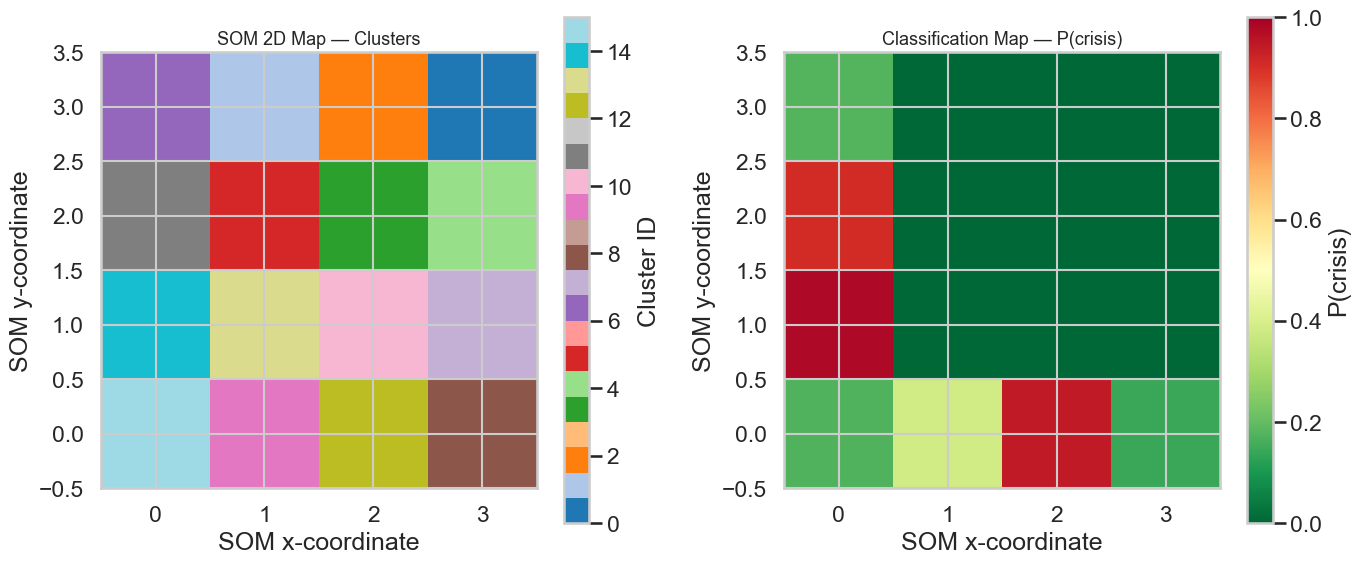

In [44]:
def plot_som_map(som, node_labels_2d, classification_results):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: SOM clusters
    axes[0].imshow(node_labels_2d, cmap='tab20', origin='lower')
    axes[0].set_title('SOM 2D Map — Clusters', fontsize=13)
    axes[0].set_xlabel('SOM x-coordinate')
    axes[0].set_ylabel('SOM y-coordinate')
    plt.colorbar(axes[0].images[0], ax=axes[0], label='Cluster ID')

    # Right: P(crisis) per node
    grid_x, grid_y = node_labels_2d.shape
    class_map = np.array([
        [classification_results[node_labels_2d[i, j]]['P_crisis']
         for j in range(grid_y)]
        for i in range(grid_x)
    ])
    im = axes[1].imshow(class_map, cmap='RdYlGn_r', origin='lower', vmin=0, vmax=1)
    axes[1].set_title('Classification Map — P(crisis)', fontsize=13)
    axes[1].set_xlabel('SOM x-coordinate')
    axes[1].set_ylabel('SOM y-coordinate')
    plt.colorbar(im, ax=axes[1], label='P(crisis)')

    plt.tight_layout()
    plt.savefig(out('NZ_SOM_map.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → NZ_SOM_map.png')


plot_som_map(som, node_labels_2d, classification_results)

### Plot B — Probabilistic Classification Maps (Non-Crisis | Crisis | Confidence)

NameError: name 'out' is not defined

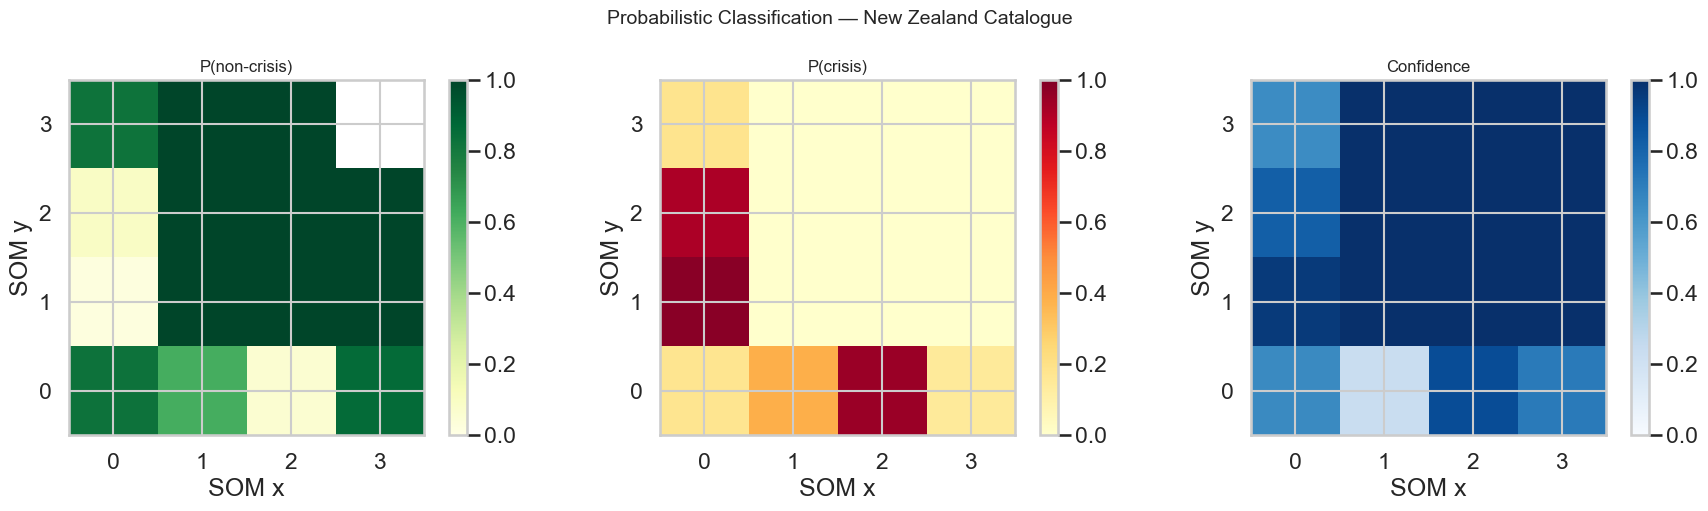

In [45]:
def plot_probability_maps(node_labels_2d, classification_results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    grid_x, grid_y = node_labels_2d.shape
    specs  = [('P(non-crisis)', 'P_non_crisis', 'YlGn'),
               ('P(crisis)',     'P_crisis',     'YlOrRd'),
               ('Confidence',   'confidence',   'Blues')]

    for ax, (title, key, cmap) in zip(axes, specs):
        grid = np.array([
            [classification_results[node_labels_2d[i, j]][key]
             for j in range(grid_y)]
            for i in range(grid_x)
        ])
        im = ax.imshow(grid, cmap=cmap, origin='lower', vmin=0, vmax=1)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('SOM x')
        ax.set_ylabel('SOM y')
        plt.colorbar(im, ax=ax)

    plt.suptitle('Probabilistic Classification — New Zealand Catalogue', fontsize=14)
    plt.tight_layout()
    plt.savefig(out('NZ_probability_maps.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → NZ_probability_maps.png')


plot_probability_maps(node_labels_2d, classification_results)

### Plot C — Spatial Map of New Zealand (Crisis vs Non-Crisis)

NameError: name 'out' is not defined

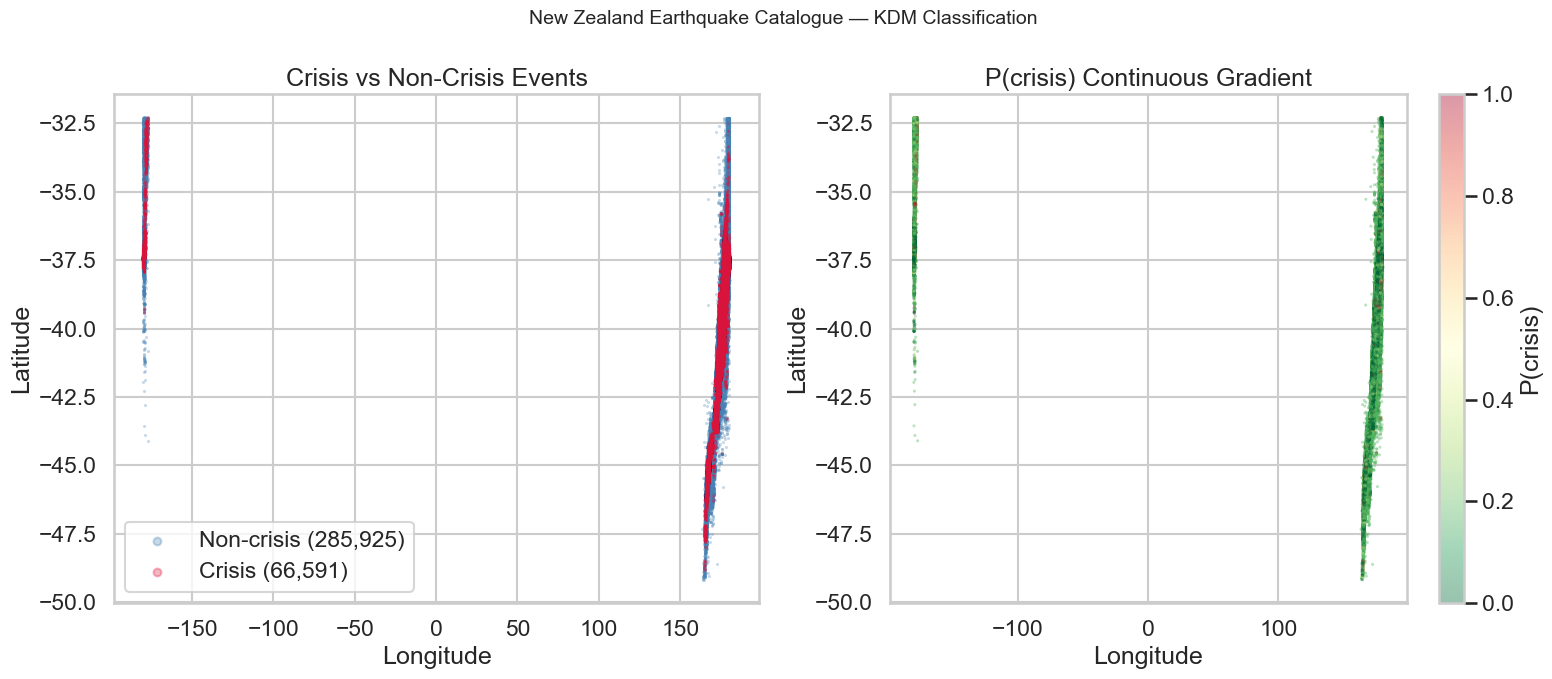

In [46]:
def plot_spatial_classification(df_labelled):
    crisis     = df_labelled[df_labelled['label'] == 'crisis']
    non_crisis = df_labelled[df_labelled['label'] == 'non_crisis']

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Panel 1: class colours
    axes[0].scatter(non_crisis['longitude'], non_crisis['latitude'],
                    c='steelblue', s=0.5, alpha=0.3,
                    label=f'Non-crisis ({len(non_crisis):,})')
    axes[0].scatter(crisis['longitude'], crisis['latitude'],
                    c='crimson', s=0.5, alpha=0.3,
                    label=f'Crisis ({len(crisis):,})')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    axes[0].set_title('Crisis vs Non-Crisis Events')
    axes[0].legend(markerscale=8)

    # Panel 2: probability gradient
    sc = axes[1].scatter(df_labelled['longitude'], df_labelled['latitude'],
                         c=df_labelled['P_crisis'], cmap='RdYlGn_r',
                         s=0.5, alpha=0.4, vmin=0, vmax=1)
    plt.colorbar(sc, ax=axes[1], label='P(crisis)')
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
    axes[1].set_title('P(crisis) Continuous Gradient')

    plt.suptitle('New Zealand Earthquake Catalogue — KDM Classification',
                 fontsize=14)
    plt.tight_layout()
    plt.savefig(out('NZ_spatial_classification.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → NZ_spatial_classification.png')


plot_spatial_classification(df_labelled)

### Plot D — Cumulative Event Curves Over Time

> **How to read:** A healthy declustering produces:
> - 📈 Non-crisis curve = roughly **linear** (constant background rate)
> - 📊 Crisis curve = **staircase** pattern (steps at major earthquake sequences)

NameError: name 'out' is not defined

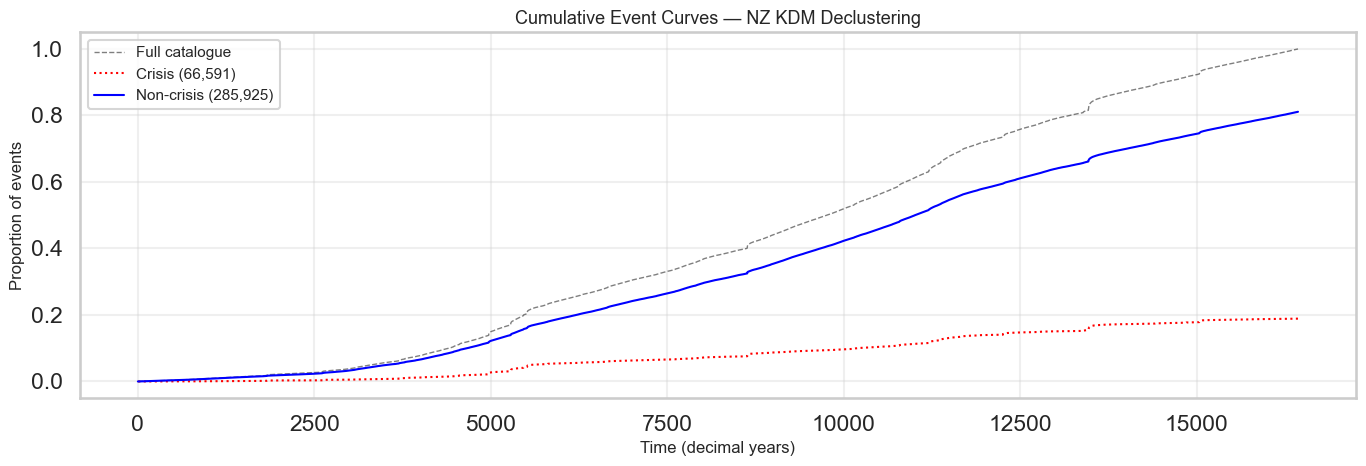

In [47]:
def plot_cumulative_curves(df_labelled):
    time_col = 'time' if 'time' in df_labelled.columns else 'Year'
    df_sorted  = df_labelled.sort_values(time_col)
    crisis     = df_sorted[df_sorted['label'] == 'crisis']
    non_crisis = df_sorted[df_sorted['label'] == 'non_crisis']
    total      = len(df_sorted)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(df_sorted[time_col], np.arange(total) / total,
            'k--', lw=1, alpha=0.5, label='Full catalogue')
    ax.plot(crisis[time_col], np.arange(len(crisis)) / total,
            'r:', lw=1.5, label=f'Crisis ({len(crisis):,})')
    ax.plot(non_crisis[time_col], np.arange(len(non_crisis)) / total,
            'b-', lw=1.5, label=f'Non-crisis ({len(non_crisis):,})')

    ax.set_xlabel('Time (decimal years)', fontsize=12)
    ax.set_ylabel('Proportion of events', fontsize=12)
    ax.set_title('Cumulative Event Curves — NZ KDM Declustering', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out('NZ_cumulative_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → NZ_cumulative_curves.png')


plot_cumulative_curves(df_labelled)

### Plot E — Magnitude Distribution by Class (like Figure 13 in paper)

NameError: name 'out' is not defined

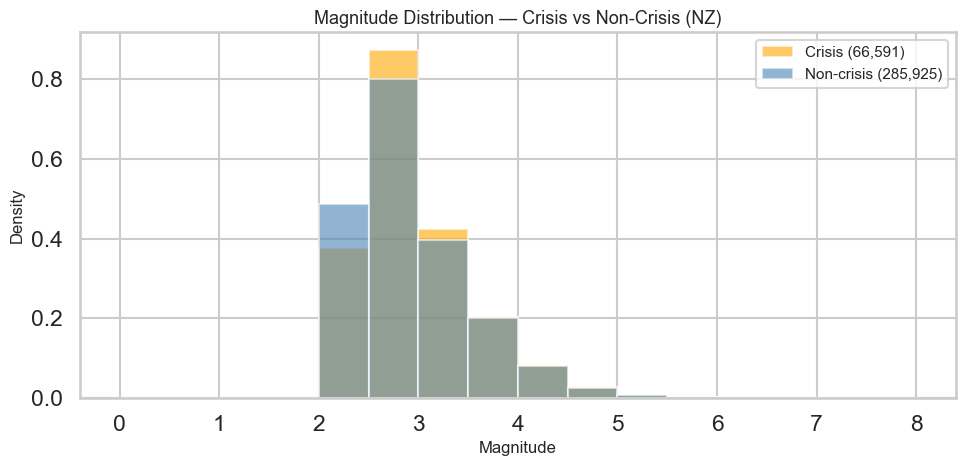

In [48]:
def plot_magnitude_distribution(df_labelled):
    crisis     = df_labelled[df_labelled['label'] == 'crisis']['magnitude']
    non_crisis = df_labelled[df_labelled['label'] == 'non_crisis']['magnitude']
    bins = np.arange(0, df_labelled['magnitude'].max() + 0.5, 0.5)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(crisis,     bins=bins, density=True, alpha=0.6,
            color='orange',   label=f'Crisis ({len(crisis):,})')
    ax.hist(non_crisis, bins=bins, density=True, alpha=0.6,
            color='steelblue', label=f'Non-crisis ({len(non_crisis):,})')
    ax.set_xlabel('Magnitude', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('Magnitude Distribution — Crisis vs Non-Crisis (NZ)', fontsize=13)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig(out('NZ_magnitude_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → NZ_magnitude_distribution.png')


plot_magnitude_distribution(df_labelled)

---
## 📊 Step 10 — Feature Importance Analysis

Three metrics from paper Section 3.3.5:

| Metric | What it shows |
|---|---|
| **Correlation** | Which features most strongly predict crisis vs non-crisis |
| **Significance** | Which features vary most across the SOM (intrinsic importance) |
| **Meaningfulness** | How distinctive each feature is for *one specific class* |

> **Expected finding (from paper):** T1–T5 and R1–R5 (nearest neighbours) dominate the classification.

NameError: name 'out' is not defined

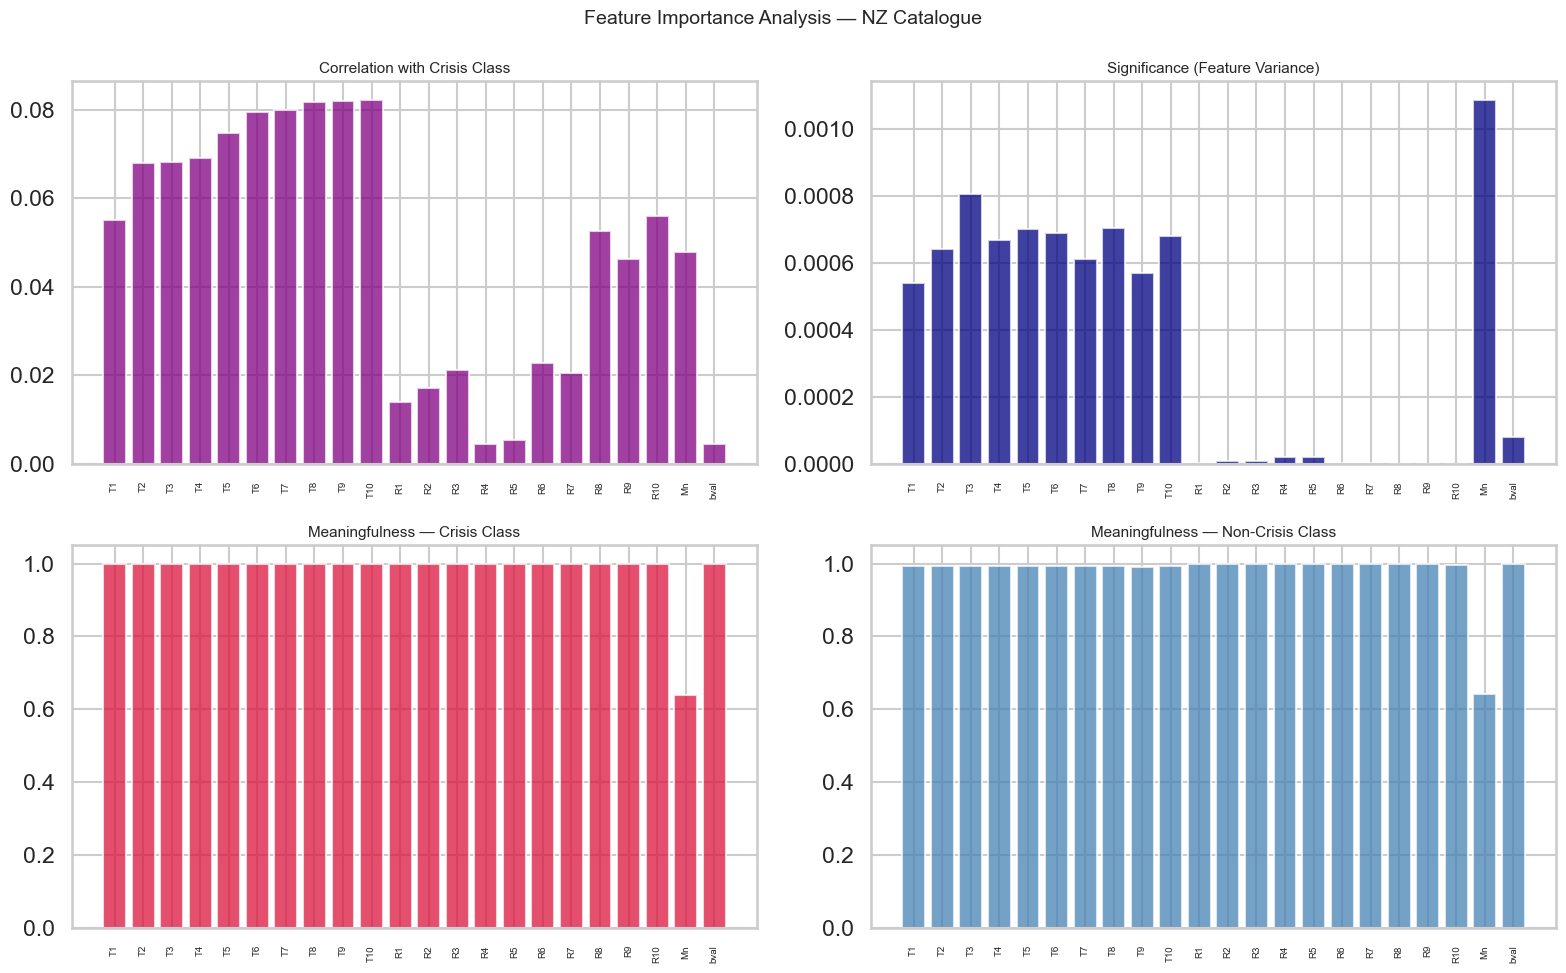

In [49]:
def compute_feature_importance(X_scaled, df_labelled, feature_cols, n_use=50_000):
    label_binary = (df_labelled['label'] == 'crisis').astype(int).values
    idx   = np.random.choice(len(X_scaled), min(n_use, len(X_scaled)), replace=False)
    X_sub = X_scaled[idx]
    y_sub = label_binary[idx]

    significance = X_sub.var(axis=0)
    X_c = X_sub[y_sub == 1]
    X_n = X_sub[y_sub == 0]

    m_crisis, m_non, corrs = [], [], []
    for f in range(X_sub.shape[1]):
        fmax = X_sub[:, f].max()
        rng  = fmax - X_sub[:, f].min() + 1e-10
        m_crisis.append((fmax - X_c[:, f].mean()) / rng)
        m_non.append((fmax - X_n[:, f].mean()) / rng)
        corrs.append(abs(np.corrcoef(X_sub[:, f], y_sub)[0, 1]))

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    x_pos = range(len(feature_cols))

    for ax, vals, title, colour in [
        (axes[0,0], corrs,       'Correlation with Crisis Class',    'purple'),
        (axes[0,1], significance,'Significance (Feature Variance)',  'navy'),
        (axes[1,0], m_crisis,    'Meaningfulness — Crisis Class',    'crimson'),
        (axes[1,1], m_non,       'Meaningfulness — Non-Crisis Class','steelblue')
    ]:
        ax.bar(x_pos, vals, color=colour, alpha=0.75)
        ax.set_title(title, fontsize=11)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(feature_cols, rotation=90, fontsize=7)

    plt.suptitle('Feature Importance Analysis — NZ Catalogue', fontsize=14)
    plt.tight_layout()
    plt.savefig(out('NZ_feature_importance.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → NZ_feature_importance.png')

    # Print top 5 features
    feat_rank = sorted(zip(feature_cols, corrs), key=lambda x: -x[1])
    print('\nTop 5 features by correlation:')
    for fname, score in feat_rank[:5]:
        print(f'  {fname:6s}  →  {score:.4f}')


compute_feature_importance(X_scaled, df_labelled, feature_cols)

---
## 💾 Step 11 — Save the Labelled Catalogue

In [50]:
def save_results(df_labelled):
    output_cols = ['event', 'DateTime', 'latitude', 'longitude', 'depth',
                   'magnitude', 'time', 'P_crisis', 'P_non_crisis',
                   'label', 'confidence', 'cluster_id']
    output_cols = [c for c in output_cols if c in df_labelled.columns]
    df_out = df_labelled[output_cols]
    filepath = out('NZ_declustered.csv')
    df_out.to_csv(filepath, index=False)
    print(f'✅ Results saved → {filepath}')
    print(f'   Total events : {len(df_out):,}')
    return df_out


df_out = save_results(df_labelled)
df_out.head(5)

NameError: name 'out' is not defined

---
## ✅ Step 12 — Final Summary

### Output Files Produced

| File | Contents |
|---|---|
| `NZ_declustered.csv` | Full catalogue with P_crisis, P_non_crisis, label, confidence |
| `NZ_SOM_map.png` | 2D SOM grid coloured by cluster & class |
| `NZ_probability_maps.png` | P(crisis), P(non-crisis), confidence maps |
| `NZ_spatial_classification.png` | NZ map coloured by class |
| `NZ_cumulative_curves.png` | Time curves — crisis (staircase) vs background (linear) |
| `NZ_magnitude_distribution.png` | Magnitude histogram by class |
| `NZ_feature_importance.png` | Which features drove the classification |

---
### Tuning Tips

| Problem | Fix |
|---|---|
| Training too slow | Reduce `N_ITERATIONS=50000` or `N_SAMPLES=3000` |
| Memory error | Add `X_scaled = X_scaled[:200000]` to subsample |
| Too many crisis events | Filter `df_out[df_out['P_crisis'] > 0.7]` |
| Unstable results | Increase `N_SAMPLES` to 140,000 |

---
*Method: Septier et al., "Unsupervised probabilistic machine learning applied to seismicity declustering" — KDM (Kohonen Map Declustering Method)*

In [53]:
# Quick stats summary
n_crisis     = (df_labelled['label'] == 'crisis').sum()
n_non_crisis = (df_labelled['label'] == 'non_crisis').sum()
n_total      = len(df_labelled)

print('══════════════════════════════════════════════')
print('  KDM DECLUSTERING — FINAL RESULTS')
print('══════════════════════════════════════════════')
print(f'  Total events   : {n_total:,}')
print(f'  Crisis         : {n_crisis:,}  ({100*n_crisis/n_total:.1f}%)')
print(f'  Non-crisis     : {n_non_crisis:,}  ({100*n_non_crisis/n_total:.1f}%)')
print(f'  High confidence: '
      f'{(df_labelled["confidence"] > 0.8).sum():,} events with conf > 0.8')
print('══════════════════════════════════════════════')

══════════════════════════════════════════════
  KDM DECLUSTERING — FINAL RESULTS
══════════════════════════════════════════════
  Total events   : 352,516
  Crisis         : 66,591  (18.9%)
  Non-crisis     : 285,925  (81.1%)
  High confidence: 150,862 events with conf > 0.8
══════════════════════════════════════════════
